In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import copy
import platform
import subprocess
import json
from io import StringIO
import numpy as np
import pandas as pd
import networkx as nx
from networkx.readwrite import json_graph
from pathlib import Path


from core.html_from_assignments import NMRProblem
import utils.json_utils as json_utils

import core.nmrsolution as nmrsolution
# from globals import svgDimensions

from config.globals import SVG_DIMENSIONS as svgDimensions
from core.simulated_annealing_symmetry import SimulatedAnnealing2

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

from matplotlib import pyplot as plt

In [3]:
%matplotlib inline

In [4]:
platform.system()

'Darwin'

In [50]:
if platform.system() == "Darwin":

    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Downloads/4Eric/caryophyllene/caryophyllene_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/OneDrive - Durham University/projects/programming/2025/python/awh/bruker_data_sets/E72507_04164043_propyl_benzoate/04164043/04164043_assignments.json")
    fn_json = Path("/opt/topspin4.5.0/examdata/exam_CMCse_1/exam_CMCse_1_assignments.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B3/Cytochalasin-B_assignments_mresnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/NMS_vsmw51_10092432_E72604_ethylbenzene/NMS_vsmw51_10092432_E72604_ethylbenzene_assignments_mresnova.json")
    # fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B-kate/Cytochalasin-B-kate_assignments_from_simplemnova.json")
    fn_json = Path("/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B-kate/Cytochalasin-B-kate_assignments_mresnova.json")

    


elif platform.system() == "Windows":
    fn_json = Path(r"C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\bruker_data_sets\E72507_04164043_propyl_benzoate\04164043\04164043_jeol_inputdata.json")
    fn_json = Path(r"Y:\downloads\Eric\student_projects\2025\simpleNMR_examples\Cytochalasin-B-kate\Cytochalasin-B-kate_assignments_mresnova.json")
    

In [51]:
print(fn_json, fn_json.exists())

/Users/vsmw51/Dropbox/4Eric/Cytochalasin-B-kate/Cytochalasin-B-kate_assignments_mresnova.json True


In [52]:
with open(fn_json, 'r') as f:
    json_data = json.load(f)

In [53]:
problemdata_json = NMRProblem.from_mnova_dict(json_data)

2026-07-07 10:46:07.969 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: hostname
2026-07-07 10:46:07.986 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: SKIP
2026-07-07 10:46:07.989 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: SKIP
2026-07-07 10:46:08.038 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: exptIdentifiers
2026-07-07 10:46:08.055 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: ml
2026-07-07 10:46:08.077 | DEBUG    | core.html_from_assignments:combine_multiple_nmrExpt_dataframes:1010 - Removed empty experiment: HSQC_0
2026-07-07 10:46:08.078 | DEBUG    | core.html_from_assignments:combine_multiple_nmrExpt_dataframes:1010 - Removed empty experiment: HMBC_0
2026-07-07 10:46:08.078 | DEBUG    | core.html_from_assig

In [54]:
solution = nmrsolution.NMRsolution(problemdata_json)

2026-07-07 10:46:13.324 | DEBUG    | core.expectedmolecule:__init__:136 - molprops_df BEFORE merge:
    idx  atom_idx  implicitHs  totalNumHs  degree  hybridization  aromatic
0     0         0           1           1       2              3      True
1     1         1           0           0       3              3      True
2     2         2           1           1       2              3      True
3     3         3           1           1       2              3      True
4     4         4           1           1       2              3      True
5     5         5           1           1       2              3      True
6     6         6           2           2       2              4     False
7     7         7           1           1       3              4     False
8     9         9           1           1       3              4     False
9    10        10           0           0       3              3     False
10   11        11           1           1       3              4     False


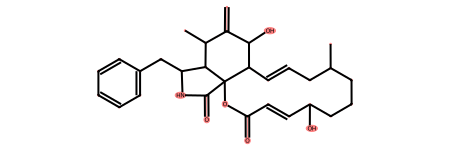

In [55]:
solution.expected_molecule

In [56]:
# mol = solution.expected_molecule.mol
# AllChem.Compute2DCoords(mol)

# # Set atom indices as map numbers for display
# for atom in mol.GetAtoms():
#     atom.SetAtomMapNum(atom.GetIdx())

# Draw.MolToImage(mol, size=(400, 400), kekulize=True, wedgeBonds=True, legend="Expected molecule")

In [57]:
solution.nmrsolution_failed

False

In [12]:
solution.expected_molecule.nmrshiftdb_failed

False

In [13]:
ok, msg = solution.init_class_from_json()
ok,msg

2026-07-07 10:40:55.767 | DEBUG    | core.nmrsolution:init_class_from_json:2098 - Indexing HSQC row: 1
2026-07-07 10:40:55.769 | DEBUG    | core.nmrsolution:init_class_from_json:2098 - Indexing HSQC row: 2
2026-07-07 10:40:55.770 | DEBUG    | core.nmrsolution:init_class_from_json:2098 - Indexing HSQC row: 3
2026-07-07 10:40:55.771 | DEBUG    | core.nmrsolution:init_class_from_json:2098 - Indexing HSQC row: 4
2026-07-07 10:40:55.772 | DEBUG    | core.nmrsolution:init_class_from_json:2098 - Indexing HSQC row: 5
2026-07-07 10:40:55.824 | DEBUG    | core.nmrsolution:init_class_from_json:2207 - HMBC row 1: f2_ppm=7.404536219277535, hsqc_C13=128.40927804252107
2026-07-07 10:40:55.826 | DEBUG    | core.nmrsolution:init_class_from_json:2207 - HMBC row 2: f2_ppm=7.404536219277535, hsqc_C13=128.40927804252107
2026-07-07 10:40:55.827 | DEBUG    | core.nmrsolution:init_class_from_json:2207 - HMBC row 3: f2_ppm=7.323510809806995, hsqc_C13=127.95479972630244
2026-07-07 10:40:55.829 | DEBUG    | core

(True, 'ok')

In [14]:
rtn_msg, rtn_num = solution.assign_CH3_CH2_CH1_overall()
rtn_msg, rtn_num

2026-07-07 10:40:57.600 | DEBUG    | core.nmrsolution:assign_CH3_CH2_CH1_overall:242 - CH3/CH2/CH1 chain: running 'Annotations'
2026-07-07 10:40:57.607 | DEBUG    | core.nmrsolution:assign_CH3_CH2_CH1_overall:242 - CH3/CH2/CH1 chain: running 'DoubleDept'
2026-07-07 10:40:57.618 | INFO     | core.nmrsolution:assign_CH3_CH2_CH1_overall:239 - CH3/CH2/CH1 assignment complete after 'H1' step


('ok', 200)

In [15]:
solution.assign_CH3_CH2_CH1_in_HSQC_using_Assignments()

In [16]:
solution.assign_CH3_CH1_in_HSQC_using_H1()

In [17]:
solution.assign_CH3_CH1_in_HSQC_using_expected_molecule()

In [18]:
solution.transfer_hsqc_info_to_c13()
solution.transfer_hsqc_info_to_h1()

In [19]:
solution.initialise_prior_to_carbon_assignment()

('ok', 200)

In [20]:
rtn_msg, rtn_num = solution.attempt_assignment_CH3_CH2_CH1_to_C13_table()
rtn_msg, rtn_num

('ok', 200)

In [21]:
solution.update_assignments_expt_dataframes()

In [22]:
G2 = nmrsolution.create_network_graph(solution.c13, solution.h1)
G2 = nmrsolution.add_all_cosy_edges_to_graph(
    G2, solution.cosy, solution.hsqc_clipcosy, solution.h1
)
G2 = nmrsolution.add_all_hmbc_edges_to_graph(
    G2, solution.hmbc, solution.h1, solution.c13
)

2026-07-07 10:41:13.505 | DEBUG    | core.nmrsolution:add_hmbc_edges_to_graph:2972 - Building HMBC edges


In [23]:
jsonGraphData = json_graph.node_link_data(G2) # reverted back to original as edges="links" was causing problems
jsonGraphData["moved_nodes"] = jsonGraphData["nodes"]
solution.initiate_molgraph( json_data, G2)

#  convert the molgraph to a json object
jsonGraphData_mol = json_graph.node_link_data(solution.molgraph) # reverted back to original as edges="links" was causing problems

# calculate the shortest paths between all pairs of nodes in the molgraph
shortest_paths = dict(nx.all_pairs_dijkstra_path_length(solution.molgraph))

/Users/vsmw51/opt/anaconda3/envs/py313/lib/python3.13/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


In [24]:
solution.expected_molecule.molprops_df.shape

(8, 27)

In [25]:
svgWidth = svgDimensions.svg_width
svgHeight = svgDimensions.svg_height
molWidth = svgDimensions.mol_width
molHeight = svgDimensions.mol_height

catoms_df = solution.expected_molecule.molprops_df[
    [
        "ppm",
        "atom_idx",
        "atomNumber",
        "numProtons",
        "x",
        "y",
        'sym_atom_idx',
        'sym_atomNumber',
    ]
].copy()

# rename ppm to ppm_calculated
catoms_df.rename(columns={"ppm": "ppm_calculated"}, inplace=True)
# renam atom_idx to id
catoms_df.rename(columns={"atom_idx": "id"}, inplace=True)

# add columns ppm, jCouplingVals, jCouplingClass, visible, H1_ppm
catoms_df["ppm"] = -1000000.0
catoms_df["jCouplingVals"] = ""
catoms_df["jCouplingClass"] = ""
catoms_df["visible"] = "false"
catoms_df["symbol"] = "C"
catoms_df["iupacLabel"] = ""

# catoms_str = json.dumps(catoms_df.to_dict(orient="records"), indent=4)
json_data_str = json.dumps(json_data, indent=4)

if problemdata_json.prediction_from_nmrshiftdb2():
    dataFrom = "nmrshiftdb2"
else:
    dataFrom = "mnova"

In [26]:
print(jsonGraphData.keys())

dict_keys(['directed', 'multigraph', 'graph', 'nodes', 'links', 'moved_nodes'])


In [27]:
jsonGraphData["nodes"][0]

{'symbol': 'C',
 'atomNumber': 1,
 'ppm': 144.33424746450788,
 'ppm_calculated': 144.0,
 'numProtons': 0,
 'iupacLabel': '',
 'jCouplingVals': '',
 'jCouplingClass': '',
 'x': 0.5,
 'y': 0.4723407371667844,
 'id': 0}

In [28]:
jsonGraphData["nodes"][0]

{'symbol': 'C',
 'atomNumber': 1,
 'ppm': 144.33424746450788,
 'ppm_calculated': 144.0,
 'numProtons': 0,
 'iupacLabel': '',
 'jCouplingVals': '',
 'jCouplingClass': '',
 'x': 0.5,
 'y': 0.4723407371667844,
 'id': 0}

In [29]:
len(jsonGraphData["nodes"])

6

In [30]:
for node in jsonGraphData["nodes"]:
    print(node['atomNumber'], node['id'], node['ppm'], node['ppm_calculated'])

1 0 144.33424746450788 144.0
3 2 128.40927804252107 128.3
2 1 127.95479972630244 127.77
4 3 125.69098496156238 125.63
7 6 28.995544901812533 29.34
8 7 15.718719355482618 15.74


In [31]:
catoms_df.shape

(8, 14)

In [32]:
for k in json_data.keys():
    print(k)

smiles
molfile
hostname
allAtomsInfo
carbonAtomsInfo
nmrAssignments
c13predictions
NMS_vsmw51_10092432.10.fid_0
NMS_vsmw51_10092432.12.ser_7
chosenSpectra
SKIP_0
SKIP_1
HSQC_0
HMBC_0
DDEPTCH3ONLY_0
HSQC_CLIPCOSY_0
MNOVAcalcMethod
exptIdentifiers
workingDirectory
workingFilename
simulatedAnnealing
ml_consent
spectraWithPeaks


In [33]:
dir(solution)

['C13indexC13label',
 'C13indexC13ppm',
 'C13labelC13index',
 'C13labelC13ppm',
 'C13ppmC13index',
 'C13ppmC13label',
 'H1indexH1label',
 'H1indexH1ppm',
 'H1labelH1index',
 'H1labelH1ppm',
 'H1ppmH1index',
 'H1ppmH1label',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_has_unresolved',
 'add_CH0_CH1_CH2_CH3_CH3CH1_to_C13',
 'add_CH0_CH1_CH2_CH3_CH3CH1_to_C13_df',
 'add_CH2_CH3CH_to_hsqc_dataframes',
 'all_molprops_df',
 'assign_CH3_CH1_in_HSQC_using_H1',
 'assign_CH3_CH1_in_HSQC_using_expected_molecule',
 'assign_CH3_CH2_CH1_in_HSQC_using_Assignments',
 'assign_CH3_CH2_CH1_in_HSQC_using_DoubleDept',
 'a

In [34]:
dir(nmrsolution.expectedmolecule)

['AllChem',
 'Chem',
 'Draw',
 'StringIO',
 'XYDIM',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'calc_c13_chemical_shifts_using_nmrshift2D',
 'defaultdict',
 'expectedMolecule',
 'get_symmetry_classes',
 'javaUtils',
 'logger',
 'lru_cache',
 'np',
 'os',
 'pd',
 'platform',
 'rdkit',
 'subprocess',
 'svgDimensions']

In [35]:
# mol = solution.expected_molecule.mol
# AllChem.Compute2DCoords(mol)

# # Set atom indices as map numbers for display
# for atom in mol.GetAtoms():
#     atom.SetAtomMapNum(atom.GetIdx())

# Draw.MolToImage(mol, size=(400, 400), kekulize=True, wedgeBonds=True, legend="Expected molecule")

In [36]:
sym_classes =nmrsolution.expectedmolecule.get_symmetry_classes(solution.expected_molecule.mol)
print(sym_classes)  
sym_list = [v for v in sym_classes.values() if len(v) > 1]
sym_list

2026-07-07 10:41:29.574 | DEBUG    | core.expectedmolecule:get_symmetry_classes:47 - Symmetry ranks: [7, 4, 2, 1, 2, 4, 6, 0]


defaultdict(<class 'list'>, {7: [0], 4: [1, 5], 2: [2, 4], 1: [3], 6: [6], 0: [7]})


[[1, 5], [2, 4]]

In [37]:
solution.expected_molecule.has_symmetry

True

In [38]:
json_data.keys()

dict_keys(['smiles', 'molfile', 'hostname', 'allAtomsInfo', 'carbonAtomsInfo', 'nmrAssignments', 'c13predictions', 'NMS_vsmw51_10092432.10.fid_0', 'NMS_vsmw51_10092432.12.ser_7', 'chosenSpectra', 'SKIP_0', 'SKIP_1', 'HSQC_0', 'HMBC_0', 'DDEPTCH3ONLY_0', 'HSQC_CLIPCOSY_0', 'MNOVAcalcMethod', 'exptIdentifiers', 'workingDirectory', 'workingFilename', 'simulatedAnnealing', 'ml_consent', 'spectraWithPeaks'])

In [39]:
simAnneal = SimulatedAnnealing2.from_params(
    copy.deepcopy(jsonGraphData["nodes"]),
    copy.deepcopy(jsonGraphData["links"]),
    json_data["molfile"]["data"]["0"],
    json_data
)

KeyError: 'possible_symmetry'

In [ ]:
simAnneal.setup_run()

In [ ]:
simAnneal.run_optimization(20)

In [ ]:
dir(simAnneal)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'all_links',
 'bestest_mapping',
 'bestest_stats',
 'bestest_weight',
 'bestest_weights',
 'bonds_subgraph',
 'calc_xy3_coords',
 'carbon_df',
 'carbon_graph',
 'carbon_grouped_nodes',
 'cooling_rate',
 'cosy_hmbc_subgraph',
 'cosy_subgraph',
 'create_graph_df',
 'from_json_file',
 'from_params',
 'graph_df',
 'hmbc_subgraph',
 'initial_mapping',
 'initial_weight',
 'initialize_mapping',
 'json_data',
 'map_protons_to_nodes',
 'mapping',
 'max_iter',
 'max_temp',
 'min_temp',
 'mol',
 'mol_graph',
 'mol_links',
 'nProtons_to_nodes',
 'nmr_graph',
 'nmr_links',
 'nmr_nodes',
 'nodes_offset',
 'orig_nodes_d

In [ ]:
simAnneal.carbon_df

,atom_idx,id,atomNumber,symbol,numProtons,ppm,ppm_calculated,iupacLabel,jCouplingVals,jCouplingClass,x,y,H1_ppm,visible,color
0,0,0,6',C,1,128.232316,128.5532,,,,0.198162,0.62078,[7.289162123422822],True,#98FB98
1,1,1,1',C,0,136.891634,137.3477,,,,0.198162,0.478213,,True,#FFA500
2,2,2,2',C,1,,,,,,,,,True,#98FB98
3,3,3,3',C,1,129.631307,128.6162,,,,0.05,0.478213,[7.1548702650533444],True,#98FB98
4,4,4,4',C,1,126.469587,127.3644,,,,0.05,0.62078,[7.207276843929239],True,#98FB98
5,5,5,5',C,1,,,,,,,,,True,#98FB98
6,6,6,10,C,2,42.650724,39.8839,,,,0.27224,0.40693,[2.8242926693886723],True,#FFFF00
7,7,7,3,C,1,53.380929,55.1041,,,,0.346318,0.478213,[3.416962796799281],True,#98FB98
9,9,9,4,C,1,47.20888,50.3224,,,,0.430588,0.453691,[2.8747326802321305],True,#98FB98
10,10,10,1,C,0,172.584056,174.1417,,,,0.434608,0.622837,,True,#FFA500


In [ ]:
# jsonGraphData, best_results = simAnneal.process_results(catoms_df, jsonGraphData)

In [ ]:

def process_results(self, catoms_df, jsonGraphData):

    best_weight = self.bestest_weight

    unique_mappings = set()
    unique_mapping_dict = {}

    for mapping in self.results[best_weight]["best_mapping"]:
        v1 = list(mapping.values())
        v1_str = "".join([str(x) for x in v1])
        #  add the string to the set
        unique_mappings.add(v1_str)
        unique_mapping_dict[v1_str] = mapping

    optimized_nodes_dicts = {}
    for k, v in unique_mapping_dict.items():
        optimized_nodes = []
        for node in self.nmr_nodes:
            moved_node = copy.deepcopy(node)
            orig_id = node["id"]
            moved_id = v[orig_id]

            if orig_id != moved_id:
                moved_node["id"] = moved_id
                moved_node["atomNumber"] = catoms_df.loc[moved_id, "atomNumber"]
                moved_node["ppm_calculated"] = catoms_df.loc[
                    moved_id, "ppm_calculated"
                ]
                moved_node["x"] = catoms_df.loc[moved_id, "x"]
                moved_node["y"] = catoms_df.loc[moved_id, "y"]
                moved_node["jCouplingVals"] = catoms_df.loc[
                    moved_id, "jCouplingVals"
                ]
                moved_node["jCouplingClass"] = catoms_df.loc[
                    moved_id, "jCouplingClass"
                ]

            optimized_nodes.append(moved_node)

        optimized_nodes_dicts[k] = optimized_nodes

    # calc MAE and LAE for each of the unique nodes_dict
    for k, optimized_nodes in optimized_nodes_dicts.items():
        mae = 0.0
        lae_biggest = 0.0
        num_carbons = 0
        lae_atomNumber = -1
        for node in optimized_nodes:
            ppm_exptal = node["ppm"]
            ppm_calculated = node["ppm_calculated"]

            try:
                ppm_exptal = float(ppm_exptal)
                ppm_calculated = float(ppm_calculated)
                lae = abs(ppm_exptal - ppm_calculated)
                mae += lae
                if lae > lae_biggest:
                    lae_biggest = lae
                    lae_atomNumber = node["atomNumber"]
                num_carbons += 1
            except:
                continue

        mae = mae / num_carbons
        optimized_nodes_dicts[k] = [
            optimized_nodes,
            mae,
            lae_biggest,
            lae_atomNumber,
        ]

    # find rows in catoms_df where sym_atom_idx is not empty
    sym_catoms_df = catoms_df[catoms_df.sym_atom_idx != ""]


In [ ]:
best_weight = simAnneal.bestest_weight

unique_mappings = set()
unique_mapping_dict = {}

for mapping in simAnneal.results[best_weight]["best_mapping"]:
    v1 = list(mapping.values())
    v1_str = "".join([str(x) for x in v1])
    #  add the string to the set
    unique_mappings.add(v1_str)
    unique_mapping_dict[v1_str] = mapping

In [ ]:
optimized_nodes_dicts = {}
for k, v in unique_mapping_dict.items():
    optimized_nodes = []
    for node in simAnneal.nmr_nodes:
        moved_node = copy.deepcopy(node)
        orig_id = node["id"]
        moved_id = v[orig_id]

        if orig_id != moved_id:
            moved_node["id"] = moved_id
            moved_node["atomNumber"] = catoms_df.loc[moved_id, "atomNumber"]
            moved_node["ppm_calculated"] = catoms_df.loc[
                moved_id, "ppm_calculated"
            ]
            moved_node["x"] = catoms_df.loc[moved_id, "x"]
            moved_node["y"] = catoms_df.loc[moved_id, "y"]
            moved_node["jCouplingVals"] = catoms_df.loc[
                moved_id, "jCouplingVals"
            ]
            moved_node["jCouplingClass"] = catoms_df.loc[
                moved_id, "jCouplingClass"
            ]

        optimized_nodes.append(moved_node)

    optimized_nodes_dicts[k] = optimized_nodes

In [ ]:
# find rows in catoms_df where sym_atom_idx is not empty
sym_catoms_df = catoms_df[catoms_df.sym_atom_idx != ""]
sym_catoms_df[['ppm', 'ppm_calculated', 'id', 'sym_atom_idx', 'atomNumber',  'sym_atomNumber']]

,ppm,ppm_calculated,id,sym_atom_idx,atomNumber,sym_atomNumber
idx,,,,,,
0,-1000000.0,128.5532,0,2,6',2'
2,-1000000.0,128.5532,2,0,2',6'
3,-1000000.0,128.6162,3,5,3',5'
5,-1000000.0,128.6162,5,3,5',3'


In [ ]:
datakeystoremove = set()
for k in unique_mapping_dict.keys():
    opt_ids = [node['id'] for node in optimized_nodes_dicts[k]]
    print(opt_ids)
    for i, row in sym_catoms_df.iterrows():
        id1 = row['id']
        id2 = int(row['sym_atom_idx'])
                        
        # check if id1 and id2 are in opt_ids
        if id1 in opt_ids and id2 in opt_ids:
            print(f"sym_atom_idx: {row['sym_atom_idx']}, id: {row['id']}, atomNumber: {row['atomNumber']}")
            datakeystoremove.add(k)


datakeystoremove

[10, 18, 21, 12, 1, 24, 2, 0, 20, 4, 19, 29, 15, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2'
[15, 18, 21, 12, 1, 24, 0, 2, 20, 4, 19, 29, 10, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2'
[10, 18, 21, 12, 1, 24, 2, 3, 20, 4, 19, 29, 15, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
[10, 18, 21, 12, 1, 24, 2, 0, 20, 4, 19, 29, 15, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2'
[15, 18, 21, 12, 1, 24, 2, 0, 20, 4, 19, 29, 10, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2'
[10, 18, 21, 12, 1, 24, 0, 2, 20, 4, 19, 29, 15, 13, 22, 7, 14, 9, 6, 23, 27, 25, 28, 11, 26, 31, 34]
sym_atom_idx: 2, id: 0, atomNumber: 6'
sym_atom_idx: 0, id: 2, atomNumber: 2

{'0132456791028121314151819202122232427262511293134',
 '0132456791528121314101819202122232427262511293134',
 '0152436791028121314151819202122232427262511293134',
 '2130456791528121314101819202122232427262511293134',
 '2150436791028121314151819202122232427262511293134',
 '2150436791528121314101819202122232427262511293134'}

In [ ]:
print("num solutions before removing sym atom solutions: ", len(optimized_nodes_dicts))
for k in datakeystoremove:
    
    del optimized_nodes_dicts[k]
print("num solutions after removing sym atom solutions: ", len(optimized_nodes_dicts))



num solutions before removing sym atom solutions:  12
num solutions after removing sym atom solutions:  6


In [ ]:
# calc MAE and LAE for each of the unique nodes_dict
for k, optimized_nodes in optimized_nodes_dicts.items():
    mae = 0.0
    lae_biggest = 0.0
    num_carbons = 0
    lae_atomNumber = -1
    for node in optimized_nodes:
        ppm_exptal = node["ppm"]
        ppm_calculated = node["ppm_calculated"]

        try:
            ppm_exptal = float(ppm_exptal)
            ppm_calculated = float(ppm_calculated)
            lae = abs(ppm_exptal - ppm_calculated)
            mae += lae
            if lae > lae_biggest:
                lae_biggest = lae
                lae_atomNumber = node["atomNumber"]
            num_carbons += 1
        except:
            continue

    mae = mae / num_carbons
    optimized_nodes_dicts[k] = [
        optimized_nodes,
        mae,
        lae_biggest,
        lae_atomNumber,
    ]

In [ ]:
# decide which is the best solution based on lowest MAE and LAE
best_mae = float("inf")
best_lae = float("inf")
best_lae_atomNumber = -1
for k, v in optimized_nodes_dicts.items():
    mae, lae, lae_atomNumber = v[1:]
    if (mae <= best_mae) and (lae <= best_lae):
        best_mae = mae
        best_lae = lae
        best_nodes = v[0]
        best_lae_atomNumber = lae_atomNumber
        best_key = k
        best_mapping = unique_mapping_dict[k]

optimized_nodes_eeh = best_nodes
best_results = {
    "best_weight": best_weight,
    "best_mae": best_mae,
    "best_lae": best_lae,
    "best_lae_atomNumber": best_lae_atomNumber,
}

for i, row in catoms_df.iterrows():
    id = row["id"] - simAnneal.nodes_offset

optimized_links = copy.deepcopy(simAnneal.nmr_links)

for link in optimized_links:
    link["source"] = best_mapping[link["source"]]
    link["target"] = best_mapping[link["target"]]

# add offset back

for node in optimized_nodes_eeh:
    node["id"] = int(node["id"]) + simAnneal.nodes_offset

for link in optimized_links:
    link["source"] = int(link["source"]) + simAnneal.nodes_offset
    link["target"] = int(link["target"]) + simAnneal.nodes_offset

jsonGraphData["nodes"] = optimized_nodes_eeh
jsonGraphData["moved_nodes"] = optimized_nodes_eeh
jsonGraphData["links"] = optimized_links

In [ ]:
best_results

{'best_weight': 0,
 'best_mae': 1.8773131114558224,
 'best_lae': 4.995031803634058,
 'best_lae_atomNumber': 11}

In [ ]:
best_mapping

{0: 3,
 1: 1,
 2: 5,
 3: 2,
 4: 4,
 5: 0,
 6: 6,
 7: 7,
 9: 9,
 10: 10,
 11: 28,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 27,
 26: 26,
 27: 25,
 28: 11,
 29: 29,
 31: 31,
 34: 34}

In [ ]:
solution.expected_molecule.molprops_df.columns

Index(['atom_idx', 'atomNumber', 'numProtons_x', 'ppm', 'implicitHs',
       'totalNumHs', 'degree', 'hybridization', 'aromatic', 'numProtons_y',
       'quaternary', 'CH0', 'CH1', 'CH2', 'CH3', 'CH3CH1', 'picked',
       'numProtons', 'ring_idx', 'ring_size', 'ring_idx0', 'ring_size0',
       'ring_idx1', 'ring_size1', 'ring_idx2', 'ring_size2', 'ring_idx3',
       'ring_size3', 'x', 'y', 'symmetry_idx1', 'symmetry_idx2',
       'sym_atom_idx', 'sym_atomNumber'],
      dtype='object')

In [ ]:
solution.expected_molecule.molprops_df[["ppm", "atom_idx", "atomNumber", "sym_atom_idx", "sym_atomNumber"]]

,ppm,atom_idx,atomNumber,sym_atom_idx,sym_atomNumber
idx,,,,,
0,128.5532,0,6',2,2'
1,137.3477,1,1',,
2,128.5532,2,2',0,6'
3,128.6162,3,3',5,5'
4,127.3644,4,4',,
5,128.6162,5,5',3,3'
6,39.8839,6,10,,
7,55.1041,7,3,,
9,50.3224,9,4,,


In [ ]:
simAnneal.carbon_df

,atom_idx,id,atomNumber,symbol,numProtons,ppm,ppm_calculated,iupacLabel,jCouplingVals,jCouplingClass,x,y,H1_ppm,visible,color
0,0,0,6',C,1,128.232316,128.5532,,,,0.198162,0.62078,[7.289162123422822],True,#98FB98
1,1,1,1',C,0,136.891634,137.3477,,,,0.198162,0.478213,,True,#FFA500
2,2,2,2',C,1,,,,,,,,,True,#98FB98
3,3,3,3',C,1,129.631307,128.6162,,,,0.05,0.478213,[7.1548702650533444],True,#98FB98
4,4,4,4',C,1,126.469587,127.3644,,,,0.05,0.62078,[7.207276843929239],True,#98FB98
5,5,5,5',C,1,,,,,,,,,True,#98FB98
6,6,6,10,C,2,42.650724,39.8839,,,,0.27224,0.40693,[2.8242926693886723],True,#FFFF00
7,7,7,3,C,1,53.380929,55.1041,,,,0.346318,0.478213,[3.416962796799281],True,#98FB98
9,9,9,4,C,1,47.20888,50.3224,,,,0.430588,0.453691,[2.8747326802321305],True,#98FB98
10,10,10,1,C,0,172.584056,174.1417,,,,0.434608,0.622837,,True,#FFA500


In [ ]:
# extract rows where ppm can be converted to float
display_carbons = simAnneal.carbon_df[pd.to_numeric(simAnneal.carbon_df['ppm'], errors='coerce').notnull()]
display_carbons

,atom_idx,id,atomNumber,symbol,numProtons,ppm,ppm_calculated,iupacLabel,jCouplingVals,jCouplingClass,x,y,H1_ppm,visible,color
0,0,0,6',C,1,128.232316,128.5532,,,,0.198162,0.62078,[7.289162123422822],True,#98FB98
1,1,1,1',C,0,136.891634,137.3477,,,,0.198162,0.478213,,True,#FFA500
3,3,3,3',C,1,129.631307,128.6162,,,,0.05,0.478213,[7.1548702650533444],True,#98FB98
4,4,4,4',C,1,126.469587,127.3644,,,,0.05,0.62078,[7.207276843929239],True,#98FB98
6,6,6,10,C,2,42.650724,39.8839,,,,0.27224,0.40693,[2.8242926693886723],True,#FFFF00
7,7,7,3,C,1,53.380929,55.1041,,,,0.346318,0.478213,[3.416962796799281],True,#98FB98
9,9,9,4,C,1,47.20888,50.3224,,,,0.430588,0.453691,[2.8747326802321305],True,#98FB98
10,10,10,1,C,0,172.584056,174.1417,,,,0.434608,0.622837,,True,#FFA500
11,11,11,5,C,1,33.147414,33.4408,,,,0.431479,0.311134,[1.245353016251815],True,#98FB98
12,12,12,6,C,0,150.044126,151.7667,,,,0.506003,0.241144,,True,#FFA500


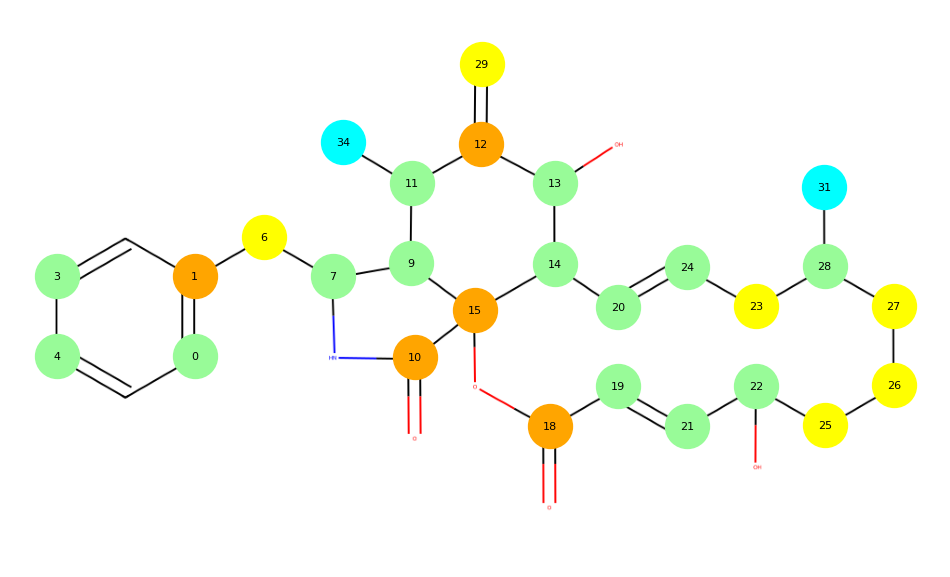

In [ ]:
mol = solution.expected_molecule.mol
# create a png image from the rdkit mol object
img = Draw.MolToImage(mol, size=(svgDimensions.mol_width, svgDimensions.mol_height))   
plt.figure(figsize=(12, 9))
plt.imshow(img)
# overlay  carbon nodes
for idx, row in display_carbons.iterrows():
    node_id = row['id']
    node_atomNumber = row['atomNumber']
    ppm = row['ppm']
    x = row['x'] * svgDimensions.mol_width
    y = row['y'] * svgDimensions.mol_height
    # get the coordinates of the node from the carbon_grouped_nodes
    color = row['color']
    # plot a circle at the coordinates with color based on ppm value
    # color = color_map.get(ppm, 'gray')  # default to gray if ppm not in color_map
    plt.scatter(x, y, color=color, s=1000)  # s is the size of the circle
    # add text label with node node_atomNumber
    plt.text(x, y, str(node_id), color='black', fontsize=8, ha='center', va='center')
plt.axis("off")  # Hide axes for better visualization
plt.show()

Node 0 mapped to 0
Node 1 mapped to 1
Node 3 mapped to 2
Node 4 mapped to 4


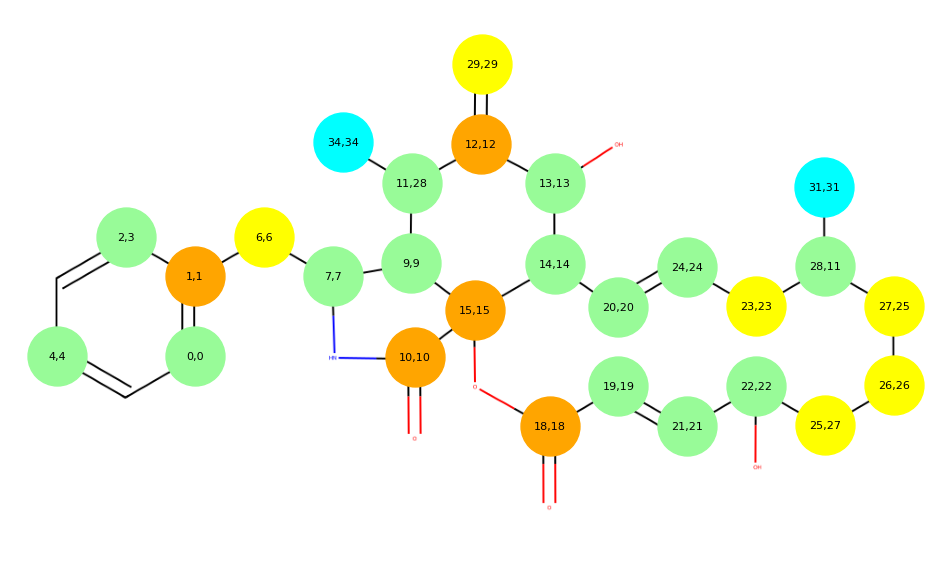

In [ ]:
# create a png image from the rdkit mol object
xy3 = simAnneal.xy3
img = Draw.MolToImage(mol, size=(svgDimensions.mol_width, svgDimensions.mol_height))   
plt.figure(figsize=(12, 9))
plt.imshow(img)
# overlay  carbon nodes
for idx, row in display_carbons.iterrows():
    node_id = row['id']
    mapped_id = simAnneal.bestest_mapping.get(node_id, None)
    if node_id < 6:
        print(f"Node {node_id} mapped to {mapped_id}")
    mapped_row = simAnneal.carbon_df[simAnneal.carbon_df['id'] == mapped_id]
    node_atomNumber = row['atomNumber']
    ppm = row['ppm']
    x = xy3[mapped_id][0] * svgDimensions.mol_width
    y = xy3[mapped_id][1] * svgDimensions.mol_height  # Assuming xy3 is a list of (x, y) coordinates
    # get the coordinates of the node from the carbon_grouped_nodes
    color = row['color']
    # plot a circle at the coordinates with color based on ppm value
    # color = color_map.get(ppm, 'gray')  # default to gray if ppm not in color_map
    plt.scatter(x, y, color=color, s=1800)  # s is the size of the circle
    # add text label with node node_atomNumber
    txt = f"{mapped_id},{node_id}"
    plt.text(x, y, txt, color='black', fontsize=8, ha='center', va='center')
plt.axis("off")  # Hide axes for better visualization
plt.show()

In [ ]:
simAnneal.bestest_mapping

{0: 0,
 1: 1,
 2: 3,
 3: 2,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 9: 9,
 10: 10,
 11: 28,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 27,
 26: 26,
 27: 25,
 28: 11,
 29: 29,
 31: 31,
 34: 34}

In [ ]:
dir(simAnneal)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'all_links',
 'bestest_mapping',
 'bestest_stats',
 'bestest_weight',
 'bestest_weights',
 'bonds_subgraph',
 'calc_xy3_coords',
 'carbon_df',
 'carbon_graph',
 'carbon_grouped_nodes',
 'cooling_rate',
 'cosy_hmbc_subgraph',
 'cosy_subgraph',
 'create_graph_df',
 'from_json_file',
 'from_params',
 'graph_df',
 'hmbc_subgraph',
 'initial_mapping',
 'initial_weight',
 'initialize_mapping',
 'json_data',
 'map_protons_to_nodes',
 'mapping',
 'max_iter',
 'max_temp',
 'min_temp',
 'mol',
 'mol_graph',
 'mol_links',
 'nProtons_to_nodes',
 'nmr_graph',
 'nmr_links',
 'nmr_nodes',
 'nodes_offset',
 'orig_nodes_d

In [ ]:
sym_classes = simAnneal.sym_classes
sym_classes

[[0, 2], [3, 5]]

In [ ]:
orig_nodes_displayed =simAnneal.orig_nodes_displayed
orig_nodes_displayed

[]

In [ ]:
dir(solution)

['C13indexC13label',
 'C13indexC13ppm',
 'C13labelC13index',
 'C13labelC13ppm',
 'C13ppmC13index',
 'C13ppmC13label',
 'H1indexH1label',
 'H1indexH1ppm',
 'H1labelH1index',
 'H1labelH1ppm',
 'H1ppmH1index',
 'H1ppmH1label',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_has_unresolved',
 'add_CH0_CH1_CH2_CH3_CH3CH1_to_C13',
 'add_CH0_CH1_CH2_CH3_CH3CH1_to_C13_df',
 'add_CH2_CH3CH_to_hsqc_dataframes',
 'all_molprops_df',
 'assign_CH3_CH1_in_HSQC_using_H1',
 'assign_CH3_CH1_in_HSQC_using_expected_molecule',
 'assign_CH3_CH2_CH1_in_HSQC_using_Assignments',
 'assign_CH3_CH2_CH1_in_HSQC_using_DoubleDept',
 'assign_CH3_CH2_CH1_overall',
 'attempt_assignme

In [ ]:
solution.c13.columns

Index(['ppm', 'numProtons', 'attached_protons', 'CH0', 'CH1', 'CH2', 'CH3',
       'CH3CH1', 'quaternary', 'ppmH1s', 'max_bonds', 'label', 'f2C_i',
       'f1C_i', 'f1_i', 'f2_i', 'atom_idx', 'sym_atom_idx', 'atomNumber',
       'sym_atomNumber', 'x', 'y', 'ppm_calculated', 'jCouplingVals',
       'jCouplingClass', 'f1_ppm', 'iupacLabel'],
      dtype='object')

In [ ]:
solution.c13[['ppm', 'ppm_calculated','numProtons','atom_idx', 'atomNumber', 'sym_atom_idx', 'sym_atomNumber']]

,ppm,ppm_calculated,numProtons,atom_idx,atomNumber,sym_atom_idx,sym_atomNumber
0,172.584056,171.10,0,10.0,1,,
1,165.047578,164.60,0,18.0,23,,
2,153.330216,152.20,1,21.0,21,,
3,150.044126,148.36,0,12.0,6,,
4,136.891634,137.50,0,1.0,1',,
5,135.395150,138.10,1,24.0,14,,
6,129.631307,129.10,1,0.0,6',2,2'
7,128.232316,129.00,1,3.0,3',5,5'
8,127.308982,126.94,1,4.0,4',,
9,126.469587,126.39,1,20.0,13,,
